# Recompute Cost Analysis — what does activation recomputation save, and what does it cost?

**The question:** we re-run every layer's forward pass a second time during backward ("full activation
recomputation") because storing the intermediate values ("activations") doesn't fit in GPU memory.
For each part of a layer: how much memory does recomputing save, and how much time does it burn?

**Terms used throughout** (defined once here):
- **microbatch (mb):** the training batch is split into 16 chunks that flow through the pipeline one at a time. "Per layer-mb" = one layer processed for one microbatch on one GPU.
- **all-to-all (a2a):** each layer routes every token to whichever GPU holds that token's assigned expert, then ships the results back. Two shipping ops plus one for the routing weights = 3 a2a per expert layer per pass.
- **DSA indexer:** the sparse-attention component that picks the top-2048 tokens each position is allowed to attend to. Runs before the attention kernel.
- **CP all-gather:** the sequence is split across the 8 GPUs in a node ("context parallelism"); before attention, each GPU gathers the pieces it needs from the others.
- **GiB/layer/mb:** gibibytes of saved activations, per layer, per in-flight microbatch, per GPU. Two microbatches are in flight at once on this pipeline (I=2), so GPU cost is 2× these numbers × layer count.

**Data sources (all measured, no modeling):**
- **Time:** `~/perf_profiles/lps-1062/pp2cp8ep8/fe127_d16_rank0.pt.trace.json` — GPU profiler trace of rank 0 (pipeline stage 0), one full step, 131k sequence length, 16 microbatches, fixed wheel (the 984 tok/s/GPU config). Method: the 608 per-layer recompute windows were reconstructed from the attention kernels inside the 16 backward phases; the boundary between "recompute" and "true backward" inside each layer = the midpoint of its 6 a2a ops (first 3 = recompute, last 3 = backward). Validation was exact: 560 windows with 6 a2a (35 expert layers × 16 mb) and 48 with 0 (3 dense layers × 16), zero anomalies.
- **Memory:** measured constants from the campaign's memory scouting (`runs/overnight_20260813_overlap_campaign/MEMORY_LEG_DECISION.md`): OOM-point fits, the 32k offload probe, and TransformerEngine source reads.

Analysis: Claude session 2026-08-19. Companion notebook: `pp2_schedule_visualization.ipynb` (same trace, pipeline-schedule view).

**Step context from the same trace:** step = 133.34 s. The pipeline schedule itself is healthy
(textbook 1F1B, bubble ≈ its theoretical floor). The expensive things are: a2a fully exposed 28.55 s
(compute provably stops dead during every one), host-side idle 20.23 s, and — the subject here —
the recompute pass at 46.4 s.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

## 1. The three passes of a step

Each step runs every layer three times: the real forward, the recompute (a second forward, run
during backward to regenerate the thrown-away activations), and the true backward. The recompute
pass re-ships one third of all a2a traffic.

In [2]:
passes = pd.DataFrame([
    # true-forward wall: 37.75s anchored on attention kernels + ~6s tail (each block's last-layer
    # expert work falls past the anchor) => ~44s
    dict(pass_name='true forward',       wall_s=44.0,  a2a_ops=1680, a2a_s=10.0),
    dict(pass_name='RECOMPUTE (in bwd)', wall_s=46.41, a2a_ops=1680, a2a_s=9.78),
    dict(pass_name='true backward',      wall_s=35.29, a2a_ops=1680, a2a_s=8.79),
]).set_index('pass_name')
STEP_WALL = 133.34
passes['pct_of_step'] = passes.wall_s / STEP_WALL * 100
passes

,wall_s,a2a_ops,a2a_s,pct_of_step
pass_name,,,,
true forward,44.000,1680,10.000,32.998
RECOMPUTE (in bwd),46.410,1680,9.780,34.806
true backward,35.290,1680,8.790,26.466


**Recompute costs 46.4 s of the 133.3 s step ≈ 35%.** Per layer-mb the recompute window is
76.3 ms (expert layers) / 76.2 ms (dense layers — only 48 of 608 windows and boundary-noisy,
so treat their per-class numbers loosely). Of the 46.4 s, 37.7 s has some kernel running and
8.7 s is idle — the per-kernel launch overhead and host-side syncs that ride along with any pass.

## 2. Where the recompute time goes (measured)

Every GPU kernel inside the 608 recompute windows, classified by name and stream.

In [3]:
t = pd.DataFrame([
    # class, step-total seconds, ms per expert-layer-mb, ms per dense-layer-mb, kernel count
    ('a2a token re-shipping',            9.78, 17.5,  0.0,   1680),
    ('elementwise glue',                 5.97,  9.7, 10.8, 148751),
    ('expert GEMMs (side streams)',      3.90,  7.0,  0.0,  35524),
    ('main GEMMs (qkv/proj/shared/rtr)', 3.75,  5.8, 10.8,  22822),
    ('CP all-gather',                    2.79,  4.7,  3.0,   1328),
    ('dispatcher gather/sort/topk',      2.68,  4.5,  3.3,  71214),
    ('DSA indexer',                      2.63,  3.3, 16.5,   1760),
    ('attention forward kernel',         2.27,  3.7,  3.7,    608),
    ('CP reduce-scatter',                1.87,  2.9,  4.6,    592),
    ('tensor concat (cat)',              1.75,  2.8,  3.6,  21999),
    ('other',                            1.13,  1.8,  2.1, 142179),
    ('rmsnorm',                          0.61,  1.0,  1.0,   5940),
    ('memcpy',                           0.23,  0.4,  0.6,  39305),
    ('IDLE (launch tax / host syncs)',   8.70, 14.3, 14.3,      0),
], columns=['class', 'total_s', 'ms_per_expert_layer_mb', 'ms_per_dense_layer_mb', 'n_kernels']).set_index('class')
print(f"class sum {t.total_s.sum():.1f}s vs 46.4s wall (side-stream GEMMs partly run concurrently)")
t

class sum 48.1s vs 46.4s wall (side-stream GEMMs partly run concurrently)


,total_s,ms_per_expert_layer_mb,ms_per_dense_layer_mb,n_kernels
class,,,,
a2a token re-shipping,9.780,17.500,0.000,1680
elementwise glue,5.970,9.700,10.800,148751
expert GEMMs (side streams),3.900,7.000,0.000,35524
main GEMMs (qkv/proj/shared/rtr),3.750,5.800,10.800,22822
CP all-gather,2.790,4.700,3.000,1328
dispatcher gather/sort/topk,2.680,4.500,3.300,71214
DSA indexer,2.630,3.300,16.500,1760
attention forward kernel,2.270,3.700,3.700,608
CP reduce-scatter,1.870,2.900,4.600,592


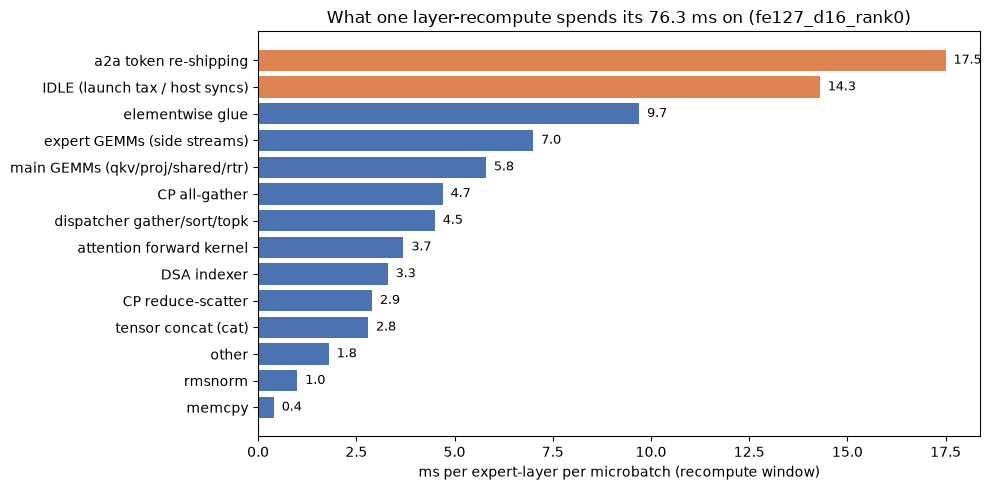

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
tt = t.sort_values('ms_per_expert_layer_mb')
colors = ['#DD8452' if ('a2a' in i or 'IDLE' in i) else '#4C72B0' for i in tt.index]
ax.barh(tt.index, tt.ms_per_expert_layer_mb, color=colors)
ax.set_xlabel('ms per expert-layer per microbatch (recompute window)')
ax.set_title('What one layer-recompute spends its 76.3 ms on (fe127_d16_rank0)')
for i, v in enumerate(tt.ms_per_expert_layer_mb):
    ax.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

A placement fact used in section 4: the CP all-gathers sit with **attention** — measured 2.51 s
of their 2.65 s lands before the attention kernel inside each window (they gather the sequence
pieces attention needs).

## 3. What recomputing saves in memory (measured census)

If we did **no** recomputation, each layer would keep a 2.94 GiB saved-tensor set per microbatch
("S_eager", pinned by fitting OOM points). With full recomputation we keep only the 0.19 GiB layer
input ("S_ckpt") — so recompute saves **2.75 GiB per layer per in-flight microbatch**. What the
2.94 is made of:

Each row rolls up into one of **four module names used consistently in the
charts and ranking below**: expert (MoE) block, core attention, attention
projections, norms / residual / glue.

In [5]:
m = pd.DataFrame([
    ('attention internals (scores/softmax state)', 0.70, 0.70, 'delta between full-eager and attention-checkpointed runs'),
    ('expert activations (fc1 out + routing wts)', 0.75, 1.15, 'measured at 32k, scaled x4 tokens'),
    ('expert combine-side saves',                  0.20, 0.25, 'derived from tensor shapes'),
    ('attention qkv-projection input',             0.20, 0.20, 'derived (hidden-sized: 16384 tok x 6144 x bf16)'),
    ('attention out-projection input',             0.20, 0.20, 'derived (hidden-sized)'),
    ('routed-expert fc1 inputs',                   0.00, 0.00, 'never saved: experts are LoRA-frozen (TE source-verified)'),
    ('remainder (norms/residual/router glue)',     0.44, 0.89, 'BY SUBTRACTION - the census gap, unmeasured'),
], columns=['module', 'gib_lo', 'gib_hi', 'provenance']).set_index('module')
m['gib_mid'] = (m.gib_lo + m.gib_hi) / 2
S_EAGER, S_CKPT = 2.94, 0.19
print(f"S_eager={S_EAGER}, S_ckpt={S_CKPT}; census rows sum to {m.gib_mid.sum():.2f} (mid) vs {S_EAGER}")
m
m['module_group'] = ['core attention', 'expert (MoE) block', 'expert (MoE) block',
                     'attention projections', 'attention projections',
                     'expert (MoE) block', 'norms / residual / glue']
m[['gib_lo', 'gib_hi', 'gib_mid', 'module_group', 'provenance']]

S_eager=2.94, S_ckpt=0.19; census rows sum to 2.94 (mid) vs 2.94


,gib_lo,gib_hi,gib_mid,module_group,provenance
module,,,,,
attention internals (scores/softmax state),0.700,0.700,0.700,core attention,delta between full-eager and attention-checkpo...
expert activations (fc1 out + routing wts),0.750,1.150,0.950,expert (MoE) block,"measured at 32k, scaled x4 tokens"
expert combine-side saves,0.200,0.250,0.225,expert (MoE) block,derived from tensor shapes
attention qkv-projection input,0.200,0.200,0.200,attention projections,derived (hidden-sized: 16384 tok x 6144 x bf16)
attention out-projection input,0.200,0.200,0.200,attention projections,derived (hidden-sized)
routed-expert fc1 inputs,0.000,0.000,0.000,expert (MoE) block,never saved: experts are LoRA-frozen (TE sourc...
remainder (norms/residual/router glue),0.440,0.890,0.665,norms / residual / glue,"BY SUBTRACTION - the census gap, unmeasured"


## 4. The four modules: memory on the left, deal quality on the right

Same four module names as section 3, same row order in both panels, so you
can read straight across: how much activation memory each module's saved
tensors take (left), and how good a bargain it is to recompute instead of
store (right — memory saved per millisecond of recompute time; **higher =
keep recomputing, lowest = stop recomputing / offload first**). Ranges are
honest uncertainty (census gap + glue/idle apportioning).

In [6]:
deals = pd.DataFrame([
    # module, GiB saved (lo, hi), recompute ms (lo, hi) per expert-layer-mb
    ('expert (MoE) block',      0.95, 1.40, 38.0, 48.0),
    ('core attention',          0.70, 0.70, 12.0, 16.0),
    ('norms / residual / glue', 0.44, 0.89,  4.5,  7.0),
    ('attention projections',   0.40, 0.40,  3.0,  4.5),
], columns=['module', 'gib_lo', 'gib_hi', 'ms_lo', 'ms_hi']).set_index('module')
deals['gib_mid'] = (deals.gib_lo + deals.gib_hi) / 2
deals['ms_mid'] = (deals.ms_lo + deals.ms_hi) / 2
deals['gib_per_ms'] = deals.gib_mid / deals.ms_mid
deals['gib_per_ms_lo'] = deals.gib_lo / deals.ms_hi
deals['gib_per_ms_hi'] = deals.gib_hi / deals.ms_lo
deals.sort_values('gib_per_ms', ascending=False)[['gib_mid', 'ms_mid', 'gib_per_ms']]

,gib_mid,ms_mid,gib_per_ms
module,,,
norms / residual / glue,0.665,5.750,0.116
attention projections,0.400,3.750,0.107
core attention,0.700,14.000,0.050
expert (MoE) block,1.175,43.000,0.027


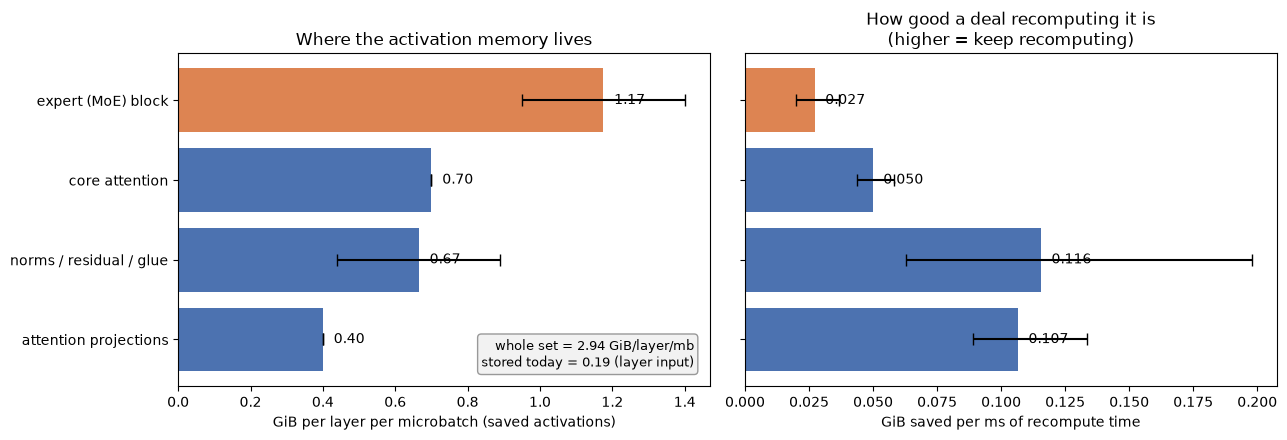

In [7]:
d = deals.sort_values('gib_mid')  # largest ends up at the top of the barh
y = np.arange(len(d))
colors = ['#DD8452' if m == 'expert (MoE) block' else '#4C72B0' for m in d.index]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

ax1.barh(y, d.gib_mid, xerr=[d.gib_mid - d.gib_lo, d.gib_hi - d.gib_mid],
         color=colors, capsize=4)
ax1.set_yticks(y); ax1.set_yticklabels(d.index)
ax1.set_xlabel('GiB per layer per microbatch (saved activations)')
ax1.set_title('Where the activation memory lives')
for yi, v in zip(y, d.gib_mid):
    ax1.text(v + 0.03, yi, f'{v:.2f}', va='center', fontsize=10)
ax1.text(0.97, 0.06, 'whole set = 2.94 GiB/layer/mb\nstored today = 0.19 (layer input)',
         transform=ax1.transAxes, ha='right', fontsize=9,
         bbox=dict(boxstyle='round', fc='#f2f2f2', ec='#999'))

ax2.barh(y, d.gib_per_ms,
         xerr=[d.gib_per_ms - d.gib_per_ms_lo, d.gib_per_ms_hi - d.gib_per_ms],
         color=colors, capsize=4)
ax2.set_xlabel('GiB saved per ms of recompute time')
ax2.set_title('How good a deal recomputing it is\n(higher = keep recomputing)')
for yi, v in zip(y, d.gib_per_ms):
    ax2.text(v + 0.004, yi, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout(); plt.show()

## 5. Conclusions

1. **Ranked (best bargain to keep recomputing → worst):** attention projections (~0.11 GiB/ms)
   ≈ norm/residual glue (~0.11) > core attention (~0.05) > **expert block (~0.027)**. The expert
   block is a 2–4× worse trade than everything else in the layer — its recompute re-runs the token
   shipping (17.5 ms), the expert GEMMs, and the dispatcher sorting, and it carries most of the
   launch-count-heavy glue, all to save ~1.2 GiB.
2. **So the order for un-recomputing is: expert block first, everything else later.** The
   expert block alone is ~43 ms of the 76 ms window → making just it eager would return
   roughly 24 s of the 46.4 s/step, for ~1.4 GiB/layer/mb of storage (109 GiB on the worst
   stage — still over the ~96 GiB headroom, so it needs the fine-grained offload hooks, which
   conveniently cover exactly these tensors, or the block+K dial).
3. Checkpoint-core-attention-only (mcore's stock `selective` mode) is the further point on the
   same frontier: eliminates ~85% of the recompute bill (~38–40 s/step) but stores 2.25
   GiB/layer/mb → 180 GiB on the worst stage; needs offload composition (the memo's valve
   arithmetic: borderline, 88–120 GiB after moe-act offload).
4. **Census gap:** the norm/residual "remainder" row is inferred by subtraction, and the
   glue/idle apportioning is approximate — a one-boot saved-tensor-hooks probe would pin every
   row. Fold into the next box boot.

**Caveats:** rank-0 / stage-0 only (stage 1 adds the loss path); dense layers carry boundary
noise (3.7 s total); whether the CP gathers re-run under `selective` depends on the exact
checkpoint scope boundary — the core-attention row's range covers both readings.